In [1]:
import numpy as np
from time import time
from numba import njit
import seaborn as sns

In [2]:
data_type="random"
nb_candidates=20

In [3]:
analysis_data=np.load(f"test_dataset/analysis_data/fine_tuning/sclarity/analysis_data_{nb_candidates}_{data_type}_fine_tuning.npy", allow_pickle=True)

In [4]:
analysis_data.item()

{'gurobi running time': 0.020672221183776856,
 'transformer greedy running time': 0.003498499393463135,
 'transformer greedy kemeny distance mean': 78.135,
 'transformer greedy kemeny distance gap': array([ 7.5 ,  7.  ,  4.5 , 13.  ,  9.75,  6.25,  9.25,  8.  ,  8.75,
         8.  ,  9.75,  3.25,  6.  ,  9.75,  6.75,  8.5 , 11.25,  8.25,
         7.  ,  5.  , 11.75,  7.25,  7.75, 14.5 ,  8.25,  9.  ,  7.5 ,
         7.5 , 11.25,  8.75, 12.5 ,  7.25,  8.5 , 11.25,  7.  ,  7.5 ,
         6.  ,  6.5 ,  5.25, 10.25,  5.25,  7.75,  9.75,  9.  ,  6.  ,
         5.5 , 13.  ,  7.5 ,  4.5 ,  7.75, 10.25, 14.  ,  8.75, 12.  ,
         9.  ,  9.75, 12.  , 16.5 ,  6.75,  7.25,  8.5 ,  9.25,  6.  ,
         9.  , 10.5 ,  7.5 ,  5.  , 11.  ,  7.25,  7.  , 13.5 , 11.25,
         7.75,  8.  ,  8.  , 10.  ,  8.  , 11.75,  9.25, 12.  , 12.25,
         6.  ,  9.5 ,  9.75, 10.75, 19.  ,  5.25, 12.5 ,  9.  ,  4.5 ,
        13.75,  6.  , 18.5 ,  2.5 ,  7.5 ,  7.75, 10.5 ,  8.5 , 13.5 ,
         7.25]),
 'tr

In [5]:
result={}
for data_type in ["random","jiggling","repeat"]:
    for nb_candidates in [20,50,100,150]:
        analysis_data=np.load(f"test_dataset/analysis_data/fine_tuning/sclarity/analysis_data_{nb_candidates}_{data_type}_fine_tuning.npy", allow_pickle=True)
        print(analysis_data.item())
        result[f"gurobi running time {nb_candidates} {data_type}"]=analysis_data.item().get("gurobi running time")
        result[f"transformer greedy running time {nb_candidates} {data_type}"]=analysis_data.item().get("transformer greedy running time")
        result[f"transformer greedy kemeny distance gap mean percent {nb_candidates} {data_type}"]=analysis_data.item().get("transformer greedy kemeny distance gap mean percent")
        


{'gurobi running time': 0.020672221183776856, 'transformer greedy running time': 0.003498499393463135, 'transformer greedy kemeny distance mean': 78.135, 'transformer greedy kemeny distance gap': array([ 7.5 ,  7.  ,  4.5 , 13.  ,  9.75,  6.25,  9.25,  8.  ,  8.75,
        8.  ,  9.75,  3.25,  6.  ,  9.75,  6.75,  8.5 , 11.25,  8.25,
        7.  ,  5.  , 11.75,  7.25,  7.75, 14.5 ,  8.25,  9.  ,  7.5 ,
        7.5 , 11.25,  8.75, 12.5 ,  7.25,  8.5 , 11.25,  7.  ,  7.5 ,
        6.  ,  6.5 ,  5.25, 10.25,  5.25,  7.75,  9.75,  9.  ,  6.  ,
        5.5 , 13.  ,  7.5 ,  4.5 ,  7.75, 10.25, 14.  ,  8.75, 12.  ,
        9.  ,  9.75, 12.  , 16.5 ,  6.75,  7.25,  8.5 ,  9.25,  6.  ,
        9.  , 10.5 ,  7.5 ,  5.  , 11.  ,  7.25,  7.  , 13.5 , 11.25,
        7.75,  8.  ,  8.  , 10.  ,  8.  , 11.75,  9.25, 12.  , 12.25,
        6.  ,  9.5 ,  9.75, 10.75, 19.  ,  5.25, 12.5 ,  9.  ,  4.5 ,
       13.75,  6.  , 18.5 ,  2.5 ,  7.5 ,  7.75, 10.5 ,  8.5 , 13.5 ,
        7.25]), 'transformer greed

In [6]:
result

{'gurobi running time 20 random': 0.020672221183776856,
 'transformer greedy running time 20 random': 0.003498499393463135,
 'transformer greedy kemeny distance gap mean percent 20 random': 0.12841547983792137,
 'gurobi running time 50 random': 0.4358087706565857,
 'transformer greedy running time 50 random': 0.0004936432838439941,
 'transformer greedy kemeny distance gap mean percent 50 random': 0.06869410715689286,
 'gurobi running time 100 random': 48.37885835409165,
 'transformer greedy running time 100 random': 0.0009919309616088867,
 'transformer greedy kemeny distance gap mean percent 100 random': 0.007843666661831002,
 'gurobi running time 150 random': 6132.385892572403,
 'transformer greedy running time 150 random': 0.0059509754180908205,
 'transformer greedy kemeny distance gap mean percent 150 random': 0.06668017818495327,
 'gurobi running time 20 jiggling': 0.018200473785400392,
 'transformer greedy running time 20 jiggling': 0.00020813941955566406,
 'transformer greedy kem

In [7]:
import pandas as pd

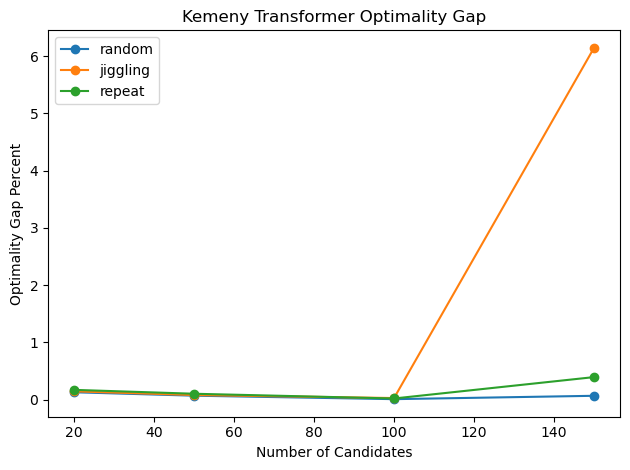

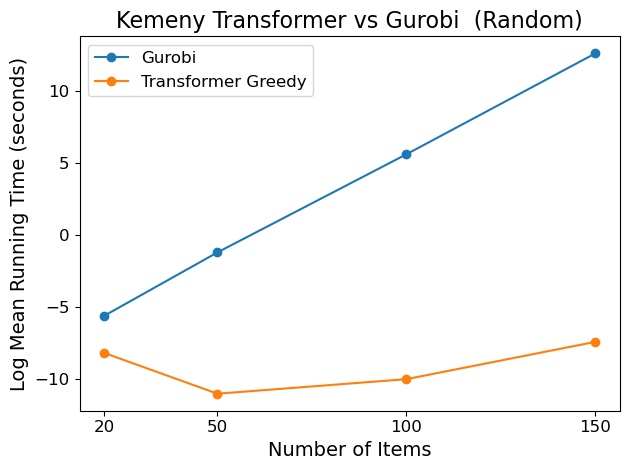

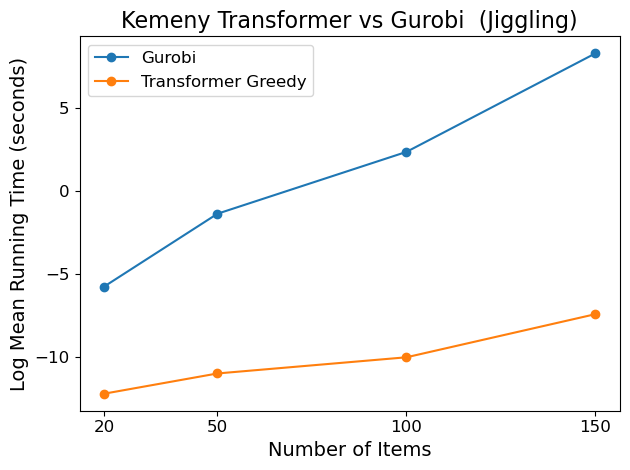

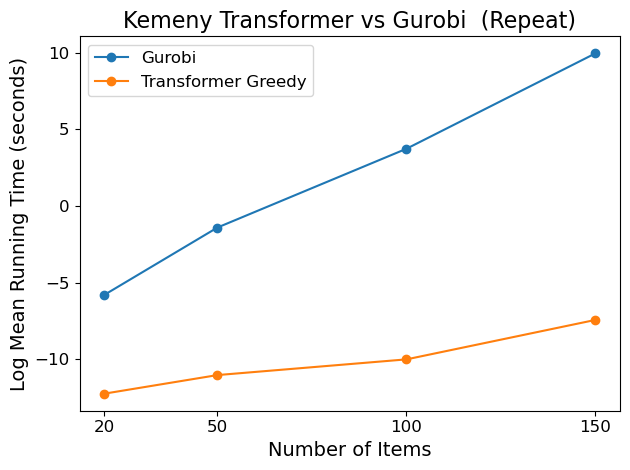

In [ ]:
import matplotlib.pyplot as plt
import os
types = ['random', 'jiggling', 'repeat']
sizes = [20, 50, 100,150]

# Plot 1: Transformer greedy kemeny distance gap for each type
plt.figure()
for t in types:
    gaps = [result[f'transformer greedy kemeny distance gap mean percent {s} {t}'] for s in sizes]
    plt.plot(sizes, gaps, marker='o', label=t)
plt.xlabel('Number of Candidates')
plt.ylabel('Optimality Gap Percent')
plt.title('Kemeny Transformer Optimality Gap')
plt.legend()
plt.tight_layout()
os.makedirs('image', exist_ok=True)
plt.savefig('image/gap.png', dpi=500, bbox_inches='tight')
plt.show()

# Plots 2-4: Running time comparisons for each data type
for t in types:
    plt.figure()
    gurobi_times = np.log2([result[f'gurobi running time {s} {t}'] for s in sizes])
    trans_times = np.log2([result[f'transformer greedy running time {s} {t}'] for s in sizes])
    plt.plot(sizes, gurobi_times, marker='o', label='Gurobi')
    plt.plot(sizes, trans_times, marker='o', label='Transformer Greedy')
    plt.xlabel('Number of Items', fontsize=14)
    plt.ylabel('Log Mean Running Time (seconds)', fontsize=14)
    plt.title(f'Kemeny Transformer vs Gurobi  ({t.capitalize()})',fontsize=16)
    plt.xticks(sizes, sizes, fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig(f'image/running time {t}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [9]:
gurobi_result_random=np.load('/home/yijun.jin/tmp/kemenyTransformer/test_dataset/gurobi_result/scalarity/test_dataset_20_random_kemeny_optimal_ranking_gurobi.npy',allow_pickle=True)

In [10]:
gurobi_result_random.item()

{'kemeny_rankings': array([[ 6.,  1.,  7., ...,  4.,  9., 12.],
        [ 7.,  9., 10., ..., 13., 18., 14.],
        [ 1., 18.,  2., ..., 19., 13., 17.],
        ...,
        [13.,  0.,  3., ...,  8., 15., 12.],
        [11., 19.,  0., ..., 10.,  8., 16.],
        [ 3.,  7., 10., ...,  0.,  5., 16.]], dtype=float32),
 'kemeny_rankings_running_time': array([0.01961637, 0.01636648, 0.01628923, 0.01697564, 0.03595734,
        0.01657629, 0.01600909, 0.01657653, 0.03400922, 0.0169065 ,
        0.01705337, 0.01605177, 0.01627064, 0.01664281, 0.01645732,
        0.01605964, 0.01703453, 0.01662183, 0.016469  , 0.01619816,
        0.01606822, 0.01599693, 0.01718664, 0.01616406, 0.03563857,
        0.03425622, 0.03299212, 0.01645756, 0.034446  , 0.01690269,
        0.0158236 , 0.01568246, 0.01634097, 0.01627159, 0.01670384,
        0.01677299, 0.0162611 , 0.03471136, 0.0162189 , 0.01708961,
        0.01667738, 0.01641512, 0.01616144, 0.01598501, 0.0151999 ,
        0.01581383, 0.03555274, 0.017

In [11]:
gurobi_result_random.item().get("kemeny_rankings_running_time")

array([0.01961637, 0.01636648, 0.01628923, 0.01697564, 0.03595734,
       0.01657629, 0.01600909, 0.01657653, 0.03400922, 0.0169065 ,
       0.01705337, 0.01605177, 0.01627064, 0.01664281, 0.01645732,
       0.01605964, 0.01703453, 0.01662183, 0.016469  , 0.01619816,
       0.01606822, 0.01599693, 0.01718664, 0.01616406, 0.03563857,
       0.03425622, 0.03299212, 0.01645756, 0.034446  , 0.01690269,
       0.0158236 , 0.01568246, 0.01634097, 0.01627159, 0.01670384,
       0.01677299, 0.0162611 , 0.03471136, 0.0162189 , 0.01708961,
       0.01667738, 0.01641512, 0.01616144, 0.01598501, 0.0151999 ,
       0.01581383, 0.03555274, 0.01729894, 0.03491187, 0.01738334,
       0.01685023, 0.01704931, 0.01638961, 0.01683021, 0.0170362 ,
       0.03312445, 0.01526856, 0.01625609, 0.01629066, 0.0348742 ,
       0.03557062, 0.01604986, 0.01595855, 0.01611018, 0.01608038,
       0.01683283, 0.01701808, 0.03702569, 0.03719234, 0.01749945,
       0.01614285, 0.01658416, 0.03666806, 0.01690912, 0.01666